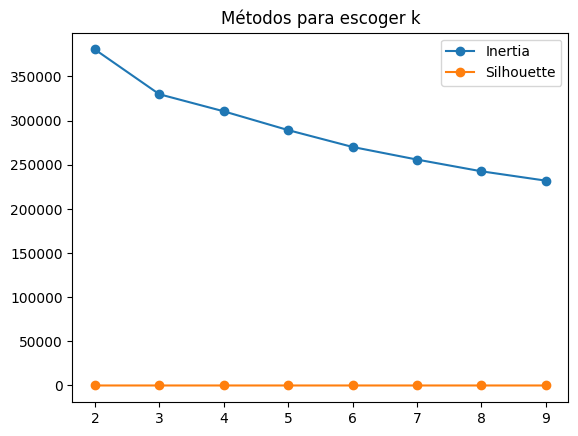

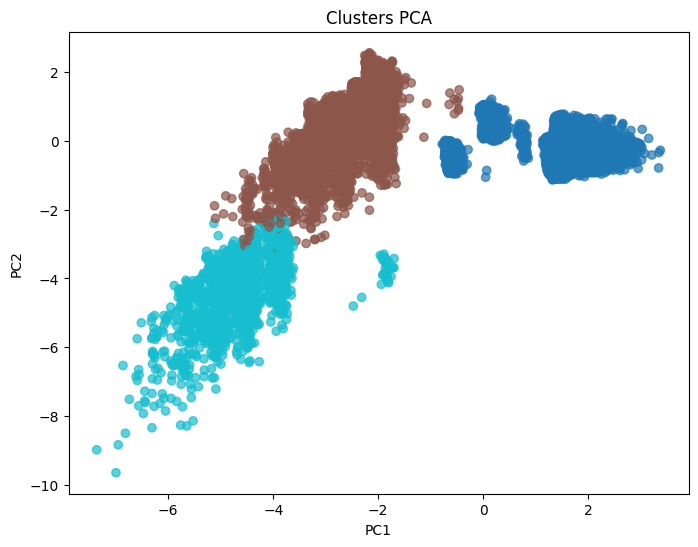

Clustering completado. Modelos guardados en models/ y datos en data/processed


In [2]:
# notebooks/03_clustering.ipynb
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from src.clustering import find_optimal_k, run_kmeans, plot_pca, save_model


# Cargar datos procesados
df = pd.read_csv("../data/processed/bank_processed.csv")
X = df.values

# Encontrar número óptimo de clusters
inertia, silhouette_scores = find_optimal_k(X, k_range=range(2,10))

# Guardar gráfica de elbow/silhouette
import matplotlib.pyplot as plt
os.makedirs("../outputs/figures", exist_ok=True)
plt.plot(range(2,10), inertia, '-o', label="Inertia")
plt.plot(range(2,10), silhouette_scores, '-o', label="Silhouette")
plt.legend()
plt.title("Métodos para escoger k")
plt.savefig("../outputs/figures/elbow_silhouette.png")
plt.show()

# Ejecutar KMeans
kmeans_model, labels = run_kmeans(X, n_clusters=3)
df['cluster'] = labels

# PCA para visualizar clusters
pca_model = plot_pca(X, labels, save_path="../outputs/figures/pca_clusters.png")

# Guardar modelos
os.makedirs("../models", exist_ok=True)
save_model(kmeans_model, "../models/kmeans_model.pkl")
save_model(pca_model, "../models/pca_model.pkl")

# Guardar datos con clusters
df.to_csv("../data/processed/bank_clusters.csv", index=False)
print("Clustering completado. Modelos guardados en models/ y datos en data/processed")
